>**⚠️ Kernel:** Click **Select Kernel** (top right) → **Python Environments...** → **conda (Python 3.10.20)**

## Setup

First, we need to import some modules and set paths & check that everything is in place.


In [ ]:
from IPython.display import Image, HTML, display
import os
import pandas as pd
import subprocess

In [ ]:
results_dir = "/biodata/results/Genome_assembly/"
resources_dir = "/biodata/resources/Genome_assembly/"
subprocess.run(f"mkdir -p {results_dir}", shell=True, check=True)
# ensure that all required resources are existing
for path_ in [
        f"{resources_dir}/raw_reads/ONT.fastq.gz",
        f"{resources_dir}/raw_reads/25748_R1.fastq.gz",
        f"{resources_dir}/raw_reads/25748_R2.fastq.gz",
        f"{resources_dir}/flye_assembly/assembly.fasta",
        f"{resources_dir}/fastqc/fastqc_R1.png",
        f"{resources_dir}/img/assembly_graph_spades.png",
        f"{resources_dir}/checkm/qa.tsv",
        f"{resources_dir}/prokka",
        f"{resources_dir}/plassembler/plassembler_plasmids.fasta",]:
    assert os.path.exists(path_), f"Resource does not exist but is required: {path_}"

# Bacterial Isolate Genome Assembly and Analysis

## Introduction

In this tutorial, we will learn how to process ONT Nanopore and Illumina sequencing data from bacterial isolates to generate high-quality genome assemblies. We will cover quality control of raw sequencing reads, genome assembly, polishing and gene prediction. We will work with a public dataset containing paired sequencing data generated with the ONT GridION sequencer and the Illumina NextSeq 2000. Accessions for downloading the raw sequencing data are given at the end of this document - for now, we want to keep the bacterial species a mystery to solve as a task of this workshop.

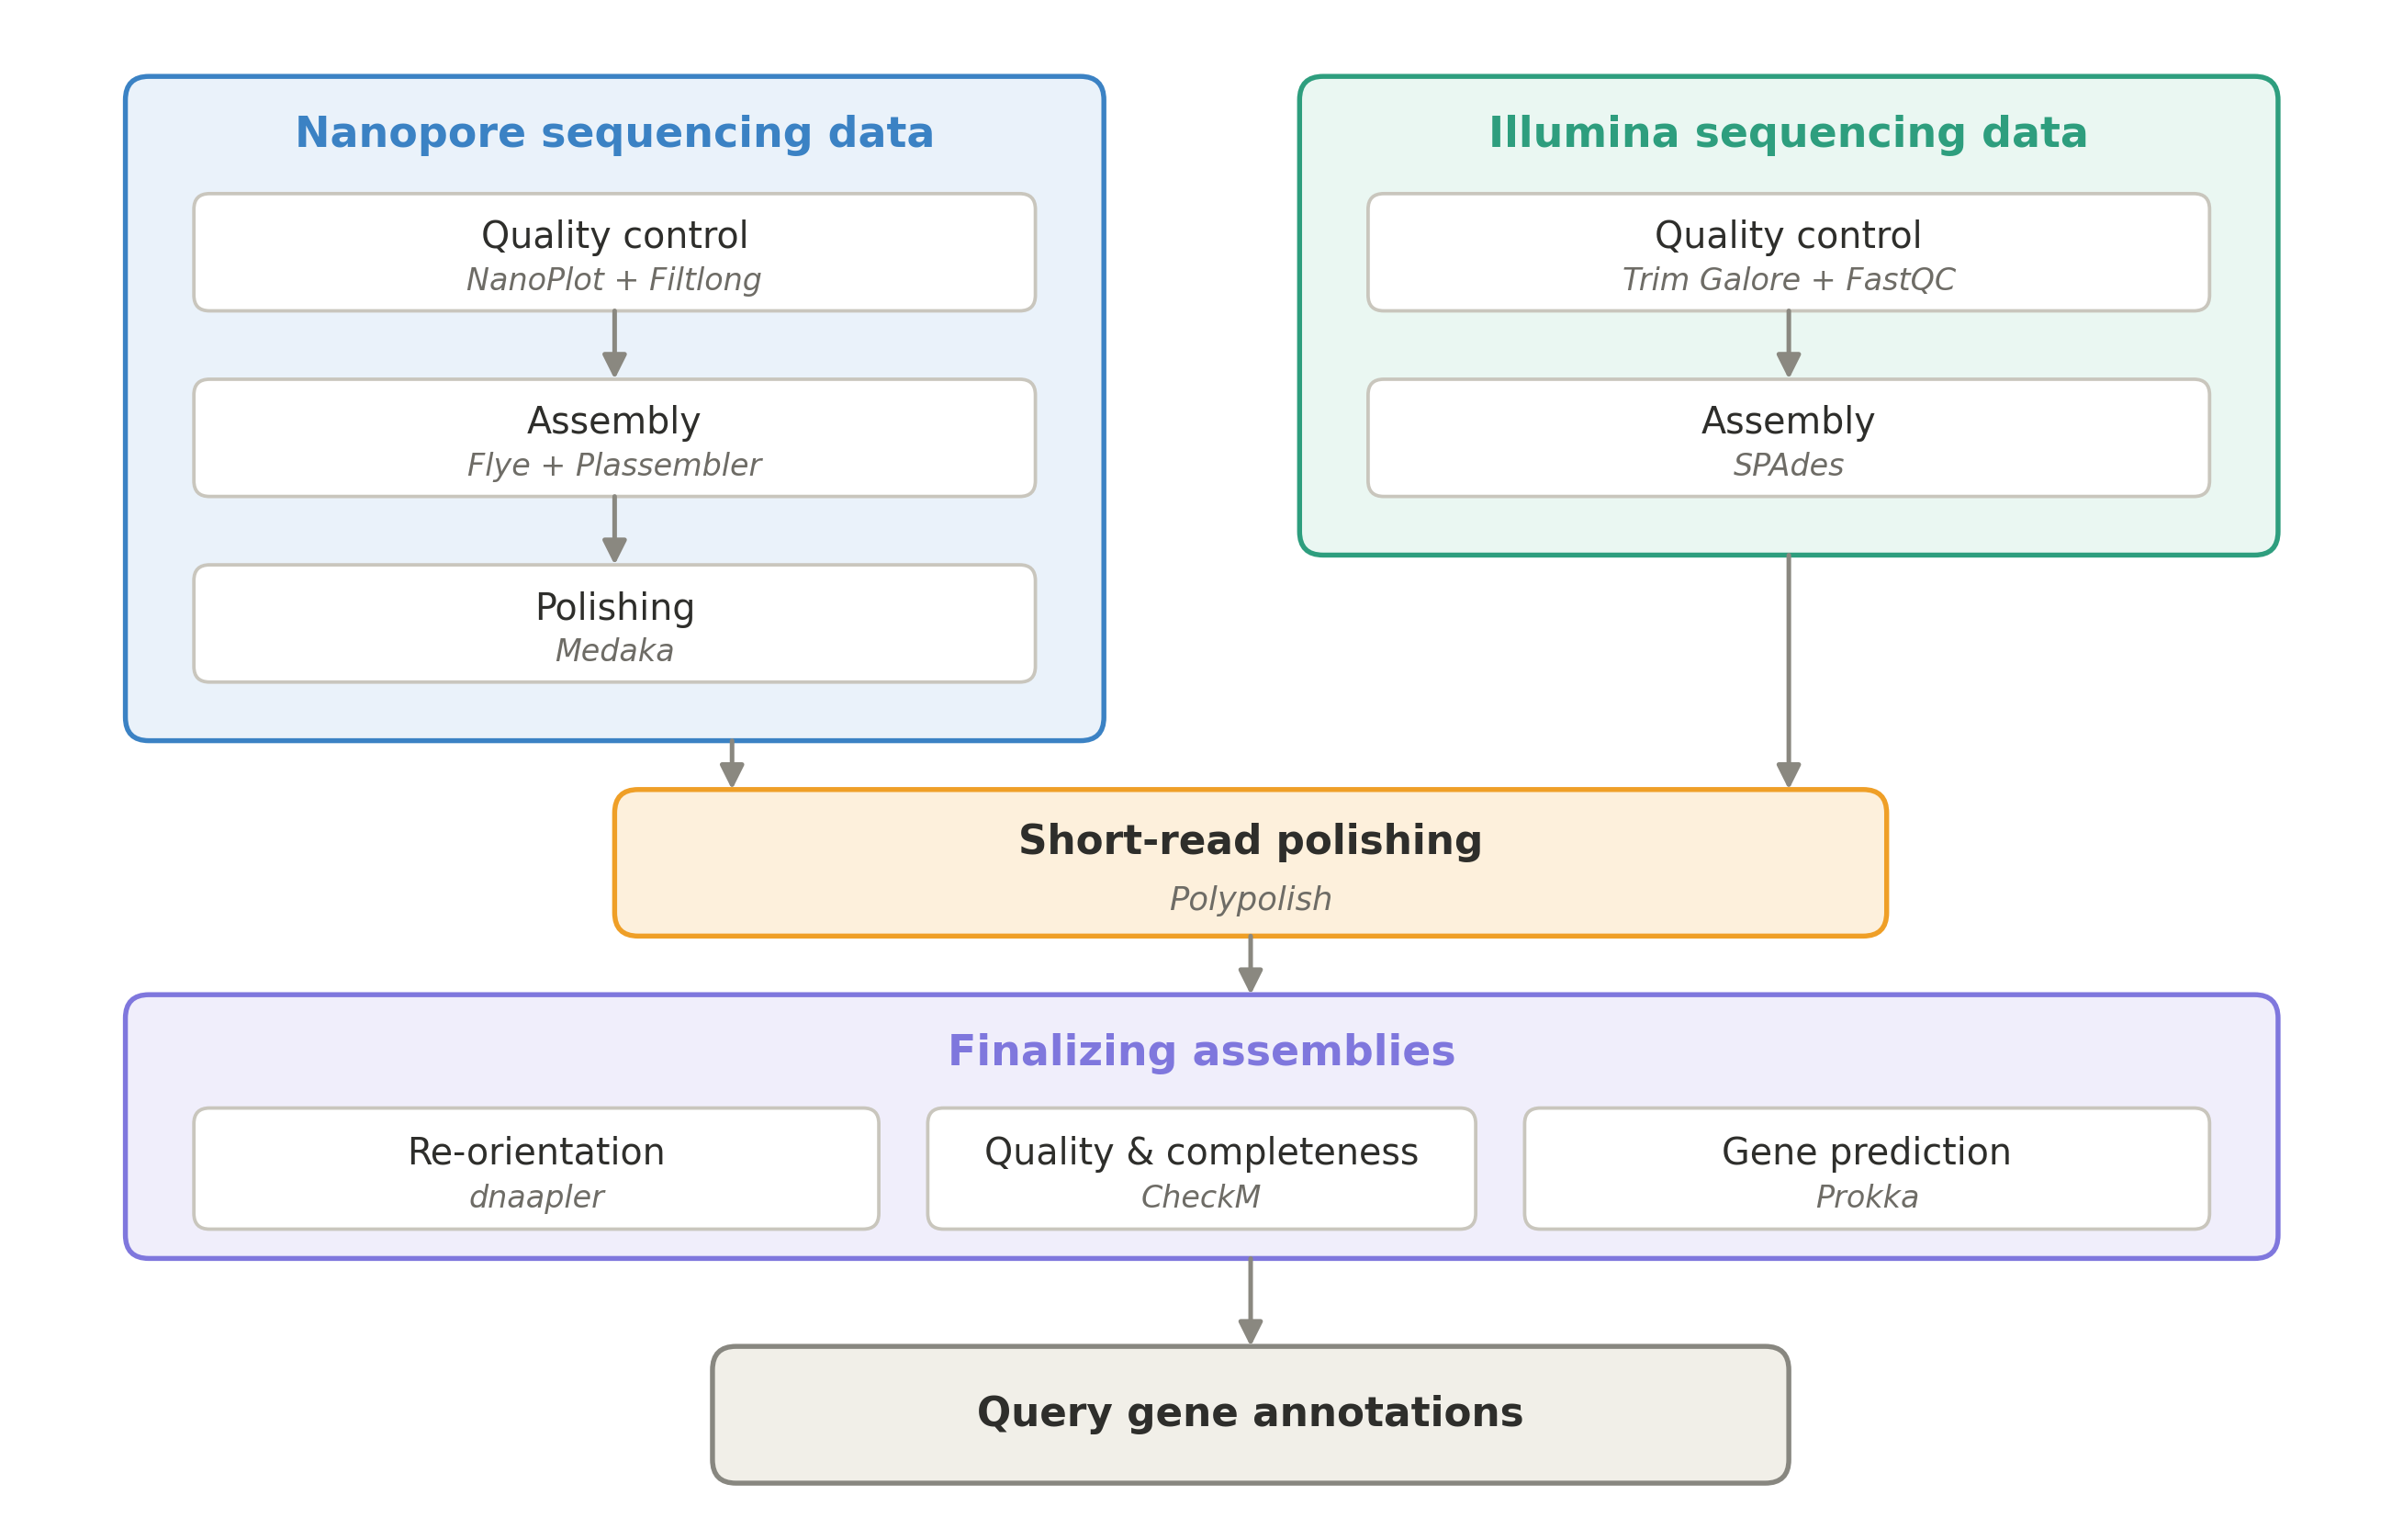

In [35]:
Image(filename=f"{resources_dir}/img/course_overview.png", width=800)

## Processing Nanopore Sequencing Data

**TL;DR** The ONT data is pre-processed for assembly, only quality control still needs to be performed

The "raw" Nanopore sequencing data used in this tutorial is already preprocessed to some degree, since it is already in FASTQ format. In contrast to Illumina data, the RAW data format of a Nanopore sequencing experiment (POD5 or FAST5) is valuable to keep, since it containes more information than stored in FASTQ files, e.g. epigenetic  information on nucleotide modifications.

After sequencing, the first step is to deduce the nucleobase sequence from the current measurements of each sequencing read - a process called **basecalling**. Most ONT sequencers have the capability to perform live-basecalling, producing FASTQ reads while the sequencing experiment is still running and new sequencing data is produced, allowing for real-time bioinformatic analyses. In out case, I used the newest available basecalling model of ONT Dorado, sup@v5.2.0, to get the highest basecalling quality currently achieveable.

Additional pre-processing steps are **demultiplexing** and **adapter trimming**. In most cases, the yield of a sequencing run is too large to sequence only a single bacterial genome, and more data would be generated than needed for assembly. The solution is multiplexing: Special sequencing adapters containing barcode sequences are used to label DNA of different samples (up to 96), before they are combined in the final steps of sequencing library preparation. Dorado automatically detects and trimms there adapters from the produced sequencing reads. The corresponding barcode is stored together with each read in a BAM file. This information can be used to demultiplex the data produced by the sequencer and to generate individual FASTQ files for each sample. 

ⓘ If you are encountering reads in FASTQ format that are not yet trimmed, you can use the tool *porechop-ABI*

For this tutorial, the sequencing data of the sequenced strain was **subsampled** to a sequencing depth of approx. 50x using the tool *rasusa* to make the data size manageable.

### Quality Control

*NanoPlot* is a useful tool to assess the quality of Nanopore sequencing data. It produces general summary statistics as a text output and plots in HTML format. The most important features are the **length** of sequencing reads and their **quality**.

The longer the reads are, the easier is the assembly. Long reads reduce the likelihood that repetetive regions of the chromosome are not spanned, which will lead to incomplete, fragmented assemblies. This is the big advantage of long read seqeuncing technologies like ONT Nanopore sequencing and PacBio SMRT sequencing.

The quality of reads is essential for generating high-quality assemblies. Low quality reads can result in mismatches or insertions / delitions (indels) in the assembly compared to the true genome sequence. Illumina short reads are of higher quality and historically, hybrid assemblies were required to ensure sufficient quality, especially for tasks like genotyping. However, with recent technological advances, the quality of ONT-only assemblies has increased. 

ⓘ Short Nanopore reads are often of lower quality than long ones, because the quality drops towards the end of sequencing reads.

In [ ]:
subprocess.run(f"NanoPlot --no_static --fastq {resources_dir}/raw_reads/ONT.fastq.gz "
          f"-o {results_dir}/NanoPlot/pre_filter/", shell=True, check=True)
subprocess.run(f"cat {results_dir}/NanoPlot/pre_filter/NanoStats.txt", shell=True, check=True)

In [ ]:
display(HTML(f"{results_dir}/NanoPlot/pre_filter/WeightedLogTransformed_HistogramReadlength.html"))
display(HTML(f"{results_dir}/NanoPlot/pre_filter/LengthvsQualityScatterPlot_dot.html"))

<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>📝 Question :</strong> What could the peak at ~3 Kbp mean?
</div>

<details>
<summary><strong>🔎 Solution :</strong></summary>

 <ul>
  <li>Individual peaks can indicate presence of high-copy plasmids</li>
  <li>For amplified sequencing libraries, they could also be PCR artifacts</b></li>
</ul> 

</details>

We will now filter the sequencing reads with the tool *filtlong*. Instead of removing all reads below a certain phread score threshold, we will remove all short reads below 1 Kbp, since they are not too useful for assembly anyways, and also only keep the 95 % of reads with the highest quality.

The reason is that by filtering strictly by quality, we might loose all reads of a small plasmid, because naturally all its reads are short and therefore of lower quality. Still, we need to inspect the histogram carefully if the length cutoff is a safe filter threshold.

In [ ]:
subprocess.run(
    f"filtlong --min_length 1000 --keep_percent 95 "
    f"{resources_dir}/raw_reads/ONT.fastq.gz > {results_dir}/ONT_filtered.fastq", 
    shell=True, check=True)

We can now re-run NanoPlot to compare how filtering affected the read stats.

In [ ]:
subprocess.run(
    f"NanoPlot --only-report --fastq {results_dir}/ONT_filtered.fastq "
    f"-o {results_dir}/NanoPlot/post_filter/", 
    shell=True, check=True)
subprocess.run(
    f"head -n15 {results_dir}/NanoPlot/post_filter/NanoStats.txt", 
    shell=True, check=True)

As you can see, the Median read length more then doubled, from 1,354 to 3,107.


We can use the tool *lrge* to get a first estimate of the genome size of the organism that was sequenced, prior to assembly.

In [ ]:
subprocess.run(f'lrge -s 0 {results_dir}/ONT_filtered.fastq', shell=True, check=True)

<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>📝 Question :</strong> What is the expected sequencing coverage for the genome?
</div>

<details>
<summary><strong>🔎 Solution :</strong></summary>

The sequencing coverage is the total number of bases divided by the expected genome size:

148.6 Mbp / 2.78 Mbp = 53.5

</details>

### Assembly

We now perform genome assembly using *flye*.

In [ ]:
subprocess.run(f'flye --nano-hq {results_dir}/ONT_filtered.fastq -o {results_dir}/flye_assembly --threads 16', shell=True, check=True)

The assembler produces several output files that are of interest:

- assembly.fasta : The assembled contig sequences
- assembly_graph.gfa : The assembly graph, storing information on how the contigs are likely arranged in the genome
- assembly_info.txt : Tabular overview of assembled contigs including their length, circularity and coverage

In [ ]:
subprocess.run(f"cat {results_dir}/flye_assembly/assembly_info.txt", shell=True, check=True)

<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>📝 Question :</strong> Why is the coverage lower than the expected coverage?
</div>

<details>
<summary><strong>🔎 Solution :</strong></summary>

<ul>
  <li>The estimated genome size was too low</li>
  <li>The organism hosts plasmids with a higher copy number than the bacterial chromosome</b></li>
</ul> 

</details>

We can now have a look at the assembly graph with the GUI application *Bandage*.

In [ ]:
Image(filename=f"{resources_dir}/img/assembly_graph_flye.png", width=600)

In this case, the graph looks very clean, with two circular contigs, one of which is the chromosome. If the chromosome can be resolved as a single, circular contig, the assembly is called a *complete genome assembly* as opposed to a *draft assembly* which is fragmented.

However, there are two non-circular contigs. In cases like this, it is adviced to look at these potential plasmids a bit closer, since plasmids often assemble incorrectly or not at all.

We therefore use BLAST to align all contigs to one another, revealing potential sequence duplications.

We display the result by loading the blastn output in "fmt6" into a pandas dataframe and filter reciprocal, low-identity and short hits.

In [ ]:
subprocess.run(f"makeblastdb -in {resources_dir}/flye_assembly/assembly.fasta -dbtype nucl", shell=True, check=True)
subprocess.run(
    f"blastn -query {resources_dir}/flye_assembly/assembly.fasta "
    f"-db {resources_dir}/flye_assembly/assembly.fasta "
    f"-task blastn -dust no -evalue 1e-20 "
    f"-outfmt '6 qseqid qlen qstart qend sseqid slen sstart send sstrand pident length' "
    f"-out {results_dir}/flye_assembly/all_blastn.tsv",
    shell=True, check=True
)

# parse the blastn results and filter for contig-contig alignments
cols = ["qseqid","qlen","qstart","qend","sseqid","slen","sstart","send",
        "sstrand","pident","length"]
df = pd.read_csv(f"{results_dir}/flye_assembly/all_blastn.tsv", sep="\t", names=cols)

# remove chromosome hits
chromosome = ["contig_3"]
df = df[~df.qseqid.isin(chromosome) & ~df.sseqid.isin(chromosome)]

# drop each contig's trivial full-length alignment to itself
df = df[~((df.qseqid == df.sseqid) & (df.qstart == 1) & (df.qend == df.qlen)
          & (df.sstart == 1) & (df.send == df.slen))]

# filter short and low-identity alignments
df = df[(df.length >= 700) & (df.pident >= 95)]

# collapse reciprocal rows
key = df.apply(lambda r: tuple(sorted([
    (r.qseqid, r.qstart, r.qend),
    (r.sseqid, min(r.sstart, r.send), max(r.sstart, r.send))])), axis=1)
df = df[~key.duplicated()]

df.sort_values(["qseqid", "qstart"]).reset_index(drop=True)[
    ['qseqid', 'qstart', 'qend', 'sseqid', 'sstart', 'send', 'pident', 'length']
]

In [ ]:
Image(filename=f"{resources_dir}/img/contig_shared_regions.png", width=800)

<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>📝 Question :</strong> How many plasmids does this isolate actually carry, and how long are they?
</div>

<details>
<summary><strong>🔎 Solution :</strong></summary>

<b>Two plasmids: ~3 kbp and ~27 kbp.</b> contig_1 and contig_4 are both artifacts, and contig_2 was ~864 bp short because the same shared element sat at its terminus and blocked circularisation. The read-length distribution reveals the true molecule size.

</details>

### Plasmid Assembly

In many cases, we can resolve plasmid assembly issues semi-automatically using *Plassembler*. This tool takes reads that don't map to the chromosome are then reassembles them on their own — with far fewer reads and no chromosomal repeats competing, small plasmids resolve cleanly. It also compares the result against PLSDB to flag known plasmids, and estimates copy number from read depth. 

Here, we won't run it due to time constraints and the database size.

In [ ]:
# resolve with plassembler (skipped due to time and space constraints)
# subprocess.run(
#   f"plassembler long -l {results_dir}/ONT_filtered.fastq -o {results_dir}/plassembler/ "
#   f"-d <plassembler_db_dir> -c 3000000 -t 32", 
#   shell=True, check=True)

In [ ]:
# stitch chromosome and plasmids into a single FASTA file for downstream analysis

# extract chromosome from assembly and rename it to "chromosome"
subprocess.run(f"samtools faidx {resources_dir}/flye_assembly/assembly.fasta contig_3 > /tmp/chromosome.fasta", shell=True, check=True)
subprocess.run("sed -i '1s/.*/>chromosome/' /tmp/chromosome.fasta", shell=True, check=True)
# extract plasmids from plassembler output and rename them to "plasmid_1", "plasmid_2", etc.
subprocess.run(f"sed 's/^>/>plasmid_/' {resources_dir}/plassembler/plassembler_plasmids.fasta > /tmp/plasmids.fasta", shell=True, check=True)
subprocess.run(f"cat /tmp/chromosome.fasta /tmp/plasmids.fasta > {results_dir}/ont_plassembler.fasta", shell=True, check=True)
subprocess.run(f"samtools faidx {results_dir}/ont_plassembler.fasta", shell=True, check=True)

### Long-read polishing

We now polish the assembly with *medaka* that uses a recurrent neural network over long reads aligned to the draft assembly to produce a corrected sequence. 

In [ ]:
subprocess.run(
    f"medaka_consensus -i {results_dir}/ONT_filtered.fastq "
    f"-d {results_dir}/ont_plassembler.fasta " 
    f"-o {results_dir}/medaka_consensus/", 
    shell=True, check=True)

## Processing Illumina sequencing data

The Illumina sequencing data is supplied in the resources directory. We will use the tool *trim-galore* to trim sequencing adapter from the reads and filter them by minimum quality and length.

In [ ]:
subprocess.run(
    f"trim_galore --quality 30 --basename 25748 --length 120 "
    f"--output_dir {results_dir}/illumina_trimmed/ "
    f"--paired {resources_dir}/raw_reads/25748_R1.fastq.gz {resources_dir}/raw_reads/25748_R2.fastq.gz", 
    shell=True, check=True
)

The tool *fastqc* generates HTML reports of Illumina read sets for Quality Control:

In [ ]:
subprocess.run(f"mkdir -p {results_dir}/fastqc_reports/", shell=True, check=True)
subprocess.run(
    f"fastqc -o {results_dir}/fastqc_reports/ "
    f"{results_dir}/illumina_trimmed/25748_val_1.fq.gz "
    f"{results_dir}/illumina_trimmed/25748_val_2.fq.gz", 
    shell=True, check=True)

In [ ]:
Image(filename=f"{resources_dir}/fastqc/fastqc_R1.png", width=600)

We can see that the mean quality of the Illumina reads is close to 40, meaning an error rate of just under 0.0001 or one error per 10 Kbps. 

Additionally, we see that there are ~200 Mbp. Since we have paired-read Illumina data, the total bases are close to 400 Mbp, which is equivalent to an estimated sequencing depth of 130x.

Let us now use *spades* for creating a Illumina-only genome assembly for comparison to the ONT-only assembly:

In [ ]:
subprocess.run(f"mkdir -p {results_dir}/spades", shell=True, check=True)
subprocess.run(
    f"spades.py --isolate -o {results_dir}/spades/ --threads 8 --memory 16 "
    f"-1 {results_dir}/illumina_trimmed/25748_val_1.fq.gz "
    f"-2 {results_dir}/illumina_trimmed/25748_val_2.fq.gz ", 
    shell=True, check=True
)

In [ ]:
Image(filename=f"{resources_dir}/img/assembly_graph_spades.png", width=600)

As we can see when visualizing the assembly in *Bandage*, it is heavily fragmented and far from being complete. In total, *spades* generated 466 contigs with 607 nodes in the assembly graph. This reveals the advantage of using long-read sequencing for genome assembly: Despite having only approximately a third of the sequencing depth, the ONT-only assembly generated a complete, circular chromosome.

# Short-Read Polishing

We can make use of the benefits of both technologies - the completeness of assemblies of long Nanopore reads and the superior quality of the short Illumina reads - by using the latter for **short–read polishing**. For this purpose, we will use the tool *PolyPolish*, which maps the short reads to all matching positions in the ONT-only assembly and then corrects genomic positions if the vast majority of bases in illumina reads at a given position is different to the base in the assembly. Due to the superior quality of the Illumina reads, it is safe to assume that in these cases, the assembly contains errors that need to be corrected.

In the following, we perform this short-read polishing step on two different assembly stages: Prior to and after the medaka polishing step, to be able to compare how well medaka polishing compares to polishing with illumina reads.

In [ ]:
subprocess.run(f"mkdir -p {results_dir}/polypolish", shell=True, check=True)
reference = f"{results_dir}/medaka_consensus/consensus.fasta"

# index the assembly
subprocess.run(f"bwa index {reference}", shell=True, check=True)
# map the short reads to it using bwa mem
subprocess.run(f"bwa mem -t 16 -a {reference} {results_dir}/illumina_trimmed/25748_val_1.fq.gz > {results_dir}/polypolish/25748_val_1.sam", shell=True, check=True)
subprocess.run(f"bwa mem -t 16 -a {reference} {results_dir}/illumina_trimmed/25748_val_2.fq.gz > {results_dir}/polypolish/25748_val_2.sam", shell=True, check=True)
# polish with polypolish
subprocess.run(f"polypolish filter "
            f"--in1  {results_dir}/polypolish/25748_val_1.sam --in2  {results_dir}/polypolish/25748_val_2.sam "
            f"--out1 {results_dir}/polypolish/filtered_1.sam  --out2 {results_dir}/polypolish/filtered_2.sam ", shell=True, check=True)
subprocess.run(f"polypolish polish --debug {results_dir}/polypolish/polished.tsv {reference} "
            f"{results_dir}/polypolish/filtered_1.sam {results_dir}/polypolish/filtered_2.sam "
            f"> {results_dir}/polypolish/polished.fasta", shell=True, check=True)
# cleanup intermediate files
subprocess.run(f"rm {results_dir}/polypolish/*.sam", shell=True, check=True)

We now read the TSV files generated by PolyPolish that summarize how many changes to the assemblies were made based on the short-read polishing:

In [ ]:
df = pd.read_csv(f"{results_dir}/polypolish/polished.tsv", sep="\t").status.value_counts().to_frame().T.set_index(pd.Index(["medaka polished"]))

df["changed"] = df.get("changed", 0)
df = df.astype({"changed": int})
df

As you can see, in this case, short-read polishing had no benefit compared to medaka polishing, since no additional changes were made. As impressive as this result is, it is important to consider that ONT-only assemblies are not always of this high quality. Several factors influence the quality of an assembly:

- DNA extraction kit 
- DNA purity and contaminant concentration
- degree of DNA fragmentation
- DNA methylation
- presence and quantity of low-complexity regions, repetitive sequences and mobile genetic elements 
- GC content
- presence and relative quantity of plasmid DNA
- homopolymer regions

## Finalizing the Assembly

The final steps of Genome assembly that need to be performed are **re-orientation**, **quality and completeness assessment** and **gene prediction**.

### Re-Orientation

Bacterial replicons - chromosomes and plasmids - are circular. However, we represent these sequences as linear in files like FASTA files. After genome assembly, the "breaking point" where the circular sequence is opened to form a linear sequence is arbitrary for each replicon. It is a convention to change that for complete genome assemblies by changing the first base to the start of certain genes, e.g. dnaA in bacterial genomes.

We will use the tool **dnaapler** to perform this re-orientation.

In [ ]:
subprocess.run(
    f"dnaapler all -i {results_dir}/polypolish/polished.fasta "
    f"-o {results_dir}/dnaapler/ -f -p polished -t 8 ", 
    shell=True, check=True)
pd.read_csv(f"{results_dir}/dnaapler/polished_all_reorientation_summary.tsv", sep="\t")

As you can see, the chromosome was re-oriented to dnaA, which is the first gene of bacterial genomes on NCBI by convention.

<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>📝 Question :</strong> What was plasmid_2 re-oriented to?
</div>

<details>
<summary><strong>🔎 Solution :</strong></summary>

The hit against UniRef90_Q48823 is a gene encoding the "Replication initiator protein A", which again indicates that this contig is not an assembly artifact but a true plasmid.

</details>

### Check Assembly Qualtity and Completeness

We are now going to use **CheckM** to control the quality and completeness of the assembly. However, since this tool requires ~40 GB of RAM, we will use precompiled results for this assembly for demonstration purposes.

In [ ]:
subprocess.run(f"mkdir -p {results_dir}/checkm", shell=True, check=True)
# CheckM requires ~40 GB of RAM, so we won't run it here
#subprocess.run(f"checkm lineage_wf -t 2 -x fasta {results_dir}/dnaapler/ {results_dir}/checkm/", shell=True, check=True)
#subprocess.run(f"checkm qa -o 2 --tab_table {results_dir}/checkm/lineage.ms {results_dir}/checkm/ -f {results_dir}/checkm/qa.tsv", shell=True, check=True)
subprocess.run(f"cp -r {resources_dir}/checkm {results_dir}/", shell=True, check=True)
pd.read_csv(f"{results_dir}/checkm/qa.tsv", sep="\t")[["Bin Id", "Marker lineage", "Completeness", "Contamination", "Strain heterogeneity"]]

As we can see, the completeness and contamination values are very close to the optimal values of 100.0 and 0.0, respectively. This indicates a really high assembly quality.

Also, we now see the genus of our isolate: *Staphylococcus* ! In fact, it is a clinically relevant *Staphylococcus aureus* strain BPH2947.

<div style="border-left: 4px solid #007acc; padding: 0.5em; background: rgba(0, 122, 204, 0.1); border-radius: 4px;">
<strong>📝 Task :</strong> Compare to published assembly
<br>
The NCBI accession number <a href="https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_045345275.1/" target="_blank">GCA_045345275.1</a> is based on the same data (without 50x subsampling).
<br>
What are possible reasons for the observed differences?
</div>

<details>
<summary><strong>🔎 Solution :</strong></summary>

<ul>
  <li>Same number of contigs with nearly identical sizes.</li>
  <li>For our assembly, the completeness is higher and contamination is lower. Reason: <b>Newer basecalling model.</b></li>
</ul> 

</details>

### Gene Prediction

The last step we perform is predicting genes from the assembly with *prokka*. Here, we load pre-computed annotations from the resource folder. 

In [ ]:
# Gene prediction with Prokka
#subprocess.run(f"prokka --outdir {results_dir}/prokka/ --prefix Saureus_BPH2947 {results_dir}/polypolish/polished_reoriented.fasta") # does not run on ARM architecture
subprocess.run(f"cp -r {resources_dir}/prokka {results_dir}/", shell=True, check=True)

# show data format
print(f"{results_dir}/prokka/Saureus_BPH2947.fna : ")
subprocess.run(f"head -n 10 {results_dir}/prokka/Saureus_BPH2947.fna", shell=True, check=True)
print(f"\n{results_dir}/prokka/Saureus_BPH2947.gff : ")
subprocess.run(f"head -n 10 {results_dir}/prokka/Saureus_BPH2947.gff", shell=True, check=True)

As you can see, the GFF file created by prokka annotated genes with start and stop coordinates, as well as predicted products. Also, note that as intended, the first gene at position 1 is dnaA.

### Taxonomic Assignment

At this point, we would perform a taxonomic assignment of our isolate using the tool *GTDB-tk*. However, this requires a large GTDB Reference Data bank, which is why it is not part of this tutorial.

### Compute True Error Rate

Finally, we can check the true error rate of Nanopore reads in this datasets when compared with the short-read polished reference assembly. We can do this using *NanoPlot* again, this time run on reads mapped to the final assembly using minimap2:

In [ ]:
subprocess.run(f"mkdir -p {results_dir}/error_rate", shell=True, check=True)
subprocess.run(f"minimap2 -ax map-ont --secondary=no {results_dir}/prokka/Saureus_BPH2947.fna {resources_dir}/raw_reads/ONT.fastq.gz >{results_dir}/error_rate/alignments.sam", shell=True, check=True)
subprocess.run(f"samtools view -bS {results_dir}/error_rate/alignments.sam | samtools sort -o {results_dir}/error_rate/alignments.sorted.bam", shell=True, check=True)
subprocess.run(f"samtools index {results_dir}/error_rate/alignments.sorted.bam", shell=True, check=True)
subprocess.run(f'NanoPlot --only-report --bam {results_dir}/error_rate/alignments.sorted.bam -o {results_dir}/error_rate/NanoPlot/', shell=True, check=True)
subprocess.run(f"head -n13 {results_dir}/error_rate/NanoPlot/NanoStats.txt", shell=True, check=True)

## Query Gene Annotations

We now want to use the gene predictions for a really simple example by seaching for antibiotic or antimicrobial resistance (AMR) genes. There are specialized tools for that process that produce more robust results, but this is just a quick demonstration:

In [ ]:
subprocess.run(f"grep resistance {results_dir}/prokka/Saureus_BPH2947.gff", shell=True, check=True)

By scanning through this output, we can see that there are genes predicted to encode products that convey resistance to antibiotics Methicillin, Quinolone, Tetracycline, Linearmycin and Bicyclomycin. In addition we found multiple heavy-metal and multidrug resistance genes.

ⓘ Note: This only shows the **genetic potential** of the strain and not if these genes are actually expressed. For this, we would need to either test for resistances directly by plating the strain on media containing antibiotics, or at least perform **RNA-seq** to see which genes are expressed.

# Resources

The sequencing data used in this tutorial was originally published by Hall *et al.* in 2024 : https://doi.org/10.7554/eLife.98300

ONT RAW data  : https://figshare.unimelb.edu.au/ndownloader/files/45334549

Illumina data : https://www.ncbi.nlm.nih.gov/sra/?term=ERR2929425
